# How Is Creativity Represented in LLMs?

## Background

In our last [computational essay](https://github.com/umairkhancis/llm-under-the-hood/blob/main/gpt_training_module/notebooks/gpt-training-essay.ipynb), we trained our `GPTModel`.

However, a trained `GPTModel` does **not** generate text directly. Its output is a set of raw scores (logits) representing how likely every token in the vocabulary is to be the next token.

It is the responsibility of the **application layer** built on top of the trained LLM to invoke the model and decode these output scores back into human-readable text.

This decoding process involves two important steps that largely determine the level of creativity perceived by the user:

* Apply **`softmax`** to convert the model's raw output scores into a probability distribution over the vocabulary.
* Select the next token from this probability distribution.

The strategy used to select the next token directly influences how deterministic or creative the generated text appears.

And that is precisely the focus of this computational essay.

## Goal

Generate different continuations for the same prompt by selecting next-token IDs using different sampling strategies instead of always choosing the token with the highest probability.

The codification of token selection process is how the creativity is represented in LLMs text generation capability and it is ultimately what the user perceives as the creativity by the model.

## Recipe
1. Write a simple text generation application on top of the trained `GPTModel`.
2. Understanding highest probabilistic sampling of next token (**greedy sampling**).
3. Understanding probabilistic distribution sampling of next token (**multinomial sampling**).
4. Understanding scaled version of probabilistic distribution sampling of next token (**temperature scaled sampling**).
5. Understanding of most probable tokens based sampling of next token (**top-k** sampling).
6. Write a sophisticated text generation application combining various techniques.

## Step 1: Write a simple text generation application on top of the trained GPTModel.

* (a): Write text generation function and helper functions.
* (b): Load the trained model parameters.
* (c): Invoke text generation function.

This simple version of text generation application will always give the same output for the same prompt which is not perceived as creativity.

### (a): Write text generation function and helper functions.

In [1]:
def simple_text_generation_app(model, input_text, max_new_tokens, context_window_size):
    
    for i in range(max_new_tokens):
        # Truncate input_text to the size limit of the context window.
        limited_context_window = input_text[:, -context_window_size:]

        # Disable computation graph of back propgation in background
        with torch.no_grad():
            logits = model(limited_context_window)

        # Extract the last index value
        logits = logits[:, -1, :]

        # Normalize for easier interpretation of logits scores as probabilities; it is optional as high scores in logits always leads to high probablities.
        probabilities = torch.softmax(logits, dim=-1)

        # Extract the index of the max value in probabilities as index represent the most likelable next_token_id which should come after the last token in the input_text.
        next_token_id = torch.argmax(probabilities, dim=-1, keepdim=True)

        # Concatenate next_token_id to the input_text.
        input_text = torch.cat((input_text, next_token_id), dim=1)

    # At the end of the loop (reaching limit of max tokens) autoregressiveness of input_text is the output_text.
    output_text = input_text
    
    return output_text

# Helper function to convert python list to tensors after invoking tokenizer to encode text into token_ids.
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

# Helper function to convert tensors back to python list and invoke tokenizer decode token_ids to text.
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

### (b): Load the trained model parameters.

In [2]:
import torch
import torch.nn as nn
import tiktoken

# Import already prepared `GPTModel` abstraction
import sys 
sys.path.append("../..")

from gpt_module import GPTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPT_CONFIG = {
    "vocab_size": 50257,          # Vocabulary size, the number of unique tokens available to be generated.
    "context_window_size": 256,   # Context window size, the maximum number of tokens model can see, learn and effectively predict on.
    "emb_dim": 768,               # Embedding dimension to capture meaning in a vector space.
    "n_heads": 12,                # Number of attention heads.
    "n_layers": 12,               # Number of transformer block layers. 
    "drop_rate": 0.1,             # Dropout rate to avoid overfitting.
    "qkv_bias": False             # Weather Query-Key-Value matrices includes bias along with weights.
}

model = GPTModel(cfg=GPT_CONFIG)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval(); # enable inference mode

torch.manual_seed(123)

### (c): Invoke `simple_text_generation_app`

In [3]:
import torch
import torch.nn
import tiktoken

context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
tokenized_context = tokenizer.encode(context)
input_sequence = torch.tensor(tokenized_context).unsqueeze(0)

next_token_ids = simple_text_generation_app(
    model=model,
    input_text=text_to_token_ids(context, tokenizer),
    max_new_tokens=10,
    context_window_size=GPT_CONFIG["context_window_size"]
)
print("umairkhancis-gpt>", token_ids_to_text(next_token_ids, tokenizer))

umairkhancis-gpt> Every effort moves you know," was one of the axioms he


**Note:** _No matter how many times you try, it will always generate the same next tokens which is obviously not perceived as creativity._

## Step 2: Understanding highest probabilistic sampling of next token (greedy sampling).

Let's try to apply this idea to a smaller example of vocabulary set of `size=9` and where output layer from model is of shape `[1, 9]`.

In [4]:
# A smaller vocabulary set of 9 tokens only.
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

# Assume for this is generated by GPTModel for this smaller example.
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

# Apply softmax for converting raw scores (logits) into probabilistic values for each token in vocabulary as next token.
probas = torch.softmax(next_token_logits, dim=0)

# Key Step: Sample based on highest probability value.
next_token_id = torch.argmax(probas).item()
print(f"Next token based on highest probabilistic sampling: {inverse_vocab[next_token_id]}")

Next token based on highest probabilistic sampling: forward


## Step 3: Understanding probabilistic distribution sampling of next token (multinomial sampling).

Let's try to apply this idea to the same smaller example of vocabulary set of `size=9` and where output layer from model is of shape `[1, 9]`.

In [5]:
# Key Step: Sample based on probability distribution.
next_token_id = torch.multinomial(probas, num_samples=1).item()

print(f"Probability distribution of vocabulary tokens being next token: {probas}\n")
print(f"Next token based on probability distribution sampling: {inverse_vocab[next_token_id]}\n")

Probability distribution of vocabulary tokens being next token: tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

Next token based on probability distribution sampling: forward



**Note:** _If you execute the previous cell multiple times you would note that next token sampled sometimes be "forward" or sometimes "toward". It is because of the fact that probability distribution says there is **57.212%** chance of "forward" being the next token and **35.758%** chance of "toward" being the next token in the input sequence._

This represents some level of creativity perceived by the user.

## Step 4: Understanding scaled version of probabilistic distribution sampling of next token (temperature scaled sampling).

Let's try to apply this idea to the same smaller example of vocabulary set of `size=9` and where output layer from model is of shape `[1, 9]`.

The `temperature` parameter in every modern LLM API request represents the level of creativity from the abstraction perspective.

Under the hood, this `temperature` is a scaling parameter of `>= 1` where;
- `temperature = 1` means same as sampling most probable token as per the distribution.
- `temperature > 1` means some less likely token will have higher chances of being sampled as probability distribution will become evenly distributed.
- `temperature < 1` means some less likely token will very low chances of being sampled as probability distribution will become skewed towards most probable tokens.

These three cases represents the creativity perception from the perspective of the forward deployed engineer while calling modern LLMs API like ChatGPT.

In [6]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

### Visualization of Scenarios

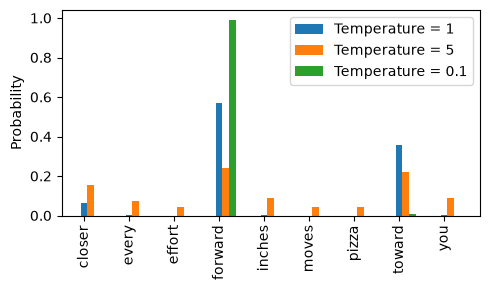

In [7]:
# Three scenarios of temperature values as equal to 1, greater than 1 and less than 1.
temperatures = [1, 5, 0.1]

# Apply temprature scaling.
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# Plot
import matplotlib.pyplot as plt
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], 
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

**Note:** _When temperature value of greater than 1 made tokens like "inches" or "closer" more likely to be sampled while diminishing their possibility when temperature value is less than 1 and magnifying the "forward" token to be sampled most of the time._

### Key Step: Sample based on temperature scaled probability distribution.

In [8]:
for i, sp in enumerate(scaled_probas):
    print(f"When `temperature={temperatures[i]}`")
    print(f"Temperature Scaled probability distribution of vocabulary tokens being next token: {sp}")
    next_token_id = torch.multinomial(sp, num_samples=1).item()
    print(f"Next token sampled: {inverse_vocab[next_token_id]}\n")

When `temperature=1`
Temperature Scaled probability distribution of vocabulary tokens being next token: tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
Next token sampled: forward

When `temperature=5`
Temperature Scaled probability distribution of vocabulary tokens being next token: tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])
Next token sampled: toward

When `temperature=0.1`
Temperature Scaled probability distribution of vocabulary tokens being next token: tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])
Next token sampled: forward



**Note:** _Next token sampled varies least when temperature value is less than 1 and varies medium when temperature value is equal to 1 and varies most when temperature value is greater than 1._

## Step 5: Understanding of most probable tokens based sampling of next token (top-k sampling).

The **temperature scaled sampling** method allows for the exploration of less likely tokens which leads to creativity in the generation process. 

However, one downside of this approach is that it sometimes leads to grammatically incorrect or completely nonsensical outputs such as `"every effort moves you pizza"`.

This is where top-k sampling technique comes to rescue:

In **top-k sampling**, we can restrict the sampled tokens to the `top-k` most likely tokens and exclude all other tokens from the selection process by masking their probability scores (totally diminishing the probability of sampling very less likely or grammatically incorrect token).

When combined with probabilistic sampling and temperature scaling, can improve the text generation results.

In [9]:
# (a): Assume for this is generated by GPTModel for this smaller example.
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])
print("Logits:", next_token_logits)

# (b): Select `top 3` mostly likely tokens out of all tokens in the vocabulary set.
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top Logits:", top_logits)
print("Indices aka tokenIDs:", top_pos)

# (c): Mask all probabilities other than top-k 
masked_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print("Masked Logits:", masked_logits)

# (d): Redistribute probability scores within top-k samples by applying `softmax`
topk_probas = torch.softmax(masked_logits, dim=0)
print("Top-k Adjusted Probability Distribution:", topk_probas)

# (f) Key Step: Sample based on probability distribution.
next_token_id = torch.multinomial(topk_probas, num_samples=1).item()
print(f"Next token based on top-k adjusted probability distribution: {inverse_vocab[next_token_id]}\n")

Logits: tensor([ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300, -1.6200, -1.8900,  6.2800,
         1.7900])
Top Logits: tensor([6.7500, 6.2800, 4.5100])
Indices aka tokenIDs: tensor([3, 7, 0])
Masked Logits: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
Top-k Adjusted Probability Distribution: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])
Next token based on top-k adjusted probability distribution: toward



**Note:** No matter how many times, you sample the token based on top-k probability distribution, it will never sample grammatically incorrect tokens like `"pizza"` for the input sequence of `every effort moves you ___.` It will hover around tokens like `"forward"` `"toward"` & `"closer".`

## Step 6: Write a sophisticated text generation application combining various techniques.

By combining top-k sampling technique with temperature scaled probablistic distribution sampling technique, we can improve the text generation results effectively balancing grammatically correct tokens sampling with creativity.

### (a): Write a sophisticated text generation function by combining the techniques.

In [12]:
def text_generation_app(model, input_text, max_new_tokens, context_window_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = input_text[:, -context_window_size:]
        
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
            
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break

        input_text = torch.cat((input_text, idx_next), dim=1)

    return input_text

### (b): Invoke `text_generation_app`

In [13]:
import torch
import torch.nn
import tiktoken

context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")
tokenized_context = tokenizer.encode(context)
input_sequence = torch.tensor(tokenized_context).unsqueeze(0)

next_token_ids = text_generation_app(
    model=model,
    input_text=text_to_token_ids(context, tokenizer),
    max_new_tokens=10,
    context_window_size=GPT_CONFIG["context_window_size"]
)
print("umairkhancis-gpt>", token_ids_to_text(next_token_ids, tokenizer))

umairkhancis-gpt> Every effort moves you know," was one of the axioms he


**Note:** 

The generated text from our trained model may still seems incoherent or grammatical incorrect because we have trained our GPTModel with very small corpus and very for a short compute time with very less number of epochs as it is only for learning purpose. 

However, the techniques demonstrated here will be effective when applied with larger corpus and more training compute time.

In the next computational essay, we will try to load the actual `GPT-2` model weights released by OpenAI in our own **(Umair's)** implementation of `GPTModel`.

## What Did We Learn?

In this computational essay, we reconstructed how a trained GPT model is transformed from a next-token predictor into a text generation system that can exhibit varying levels of creativity.

We learned:

* A trained **GPT model** does not generate text directly; it only predicts a score (logit) for every token in the vocabulary.
* The **application layer** is responsible for decoding these scores into human-readable text.
* How **greedy sampling** always selects the highest-probability token, producing deterministic outputs for the same prompt.
* How **multinomial sampling** selects tokens according to the model's probability distribution, allowing different continuations for the same prompt.
* How **temperature scaling** reshapes the probability distribution, giving application engineers a simple control over the perceived creativity of the generated text.
* How **Top-K sampling** restricts token selection to the most probable candidates, reducing the likelihood of grammatically incorrect or nonsensical outputs.
* How combining **temperature scaling** with **Top-K sampling** provides a practical balance between creativity and coherence in modern LLM applications.

The most important insight is that **creativity is not learned by a separate component inside the LLM**. The trained model simply predicts a probability distribution over the next token. What users perceive as creativity emerges from **how the application samples tokens from that distribution**.

This explains why the same trained LLM can produce highly deterministic responses for one application and highly creative responses for another—the difference lies in the **decoding strategy**, not in the underlying model itself.